## Handwriting

Define the needed functions

In [7]:
import numpy as np
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.manifold import Isomap
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay

def discrete_cmap(N, base_cmap=None):
    """Create an N-bin discrete colormap from the specified input map"""
    base = plt.colormaps[base_cmap]
    color_list = base(np.linspace(0, 1, N))
    cmap_name = base.name + str(N)
    return base.from_list(cmap_name, color_list, N)

Load the data

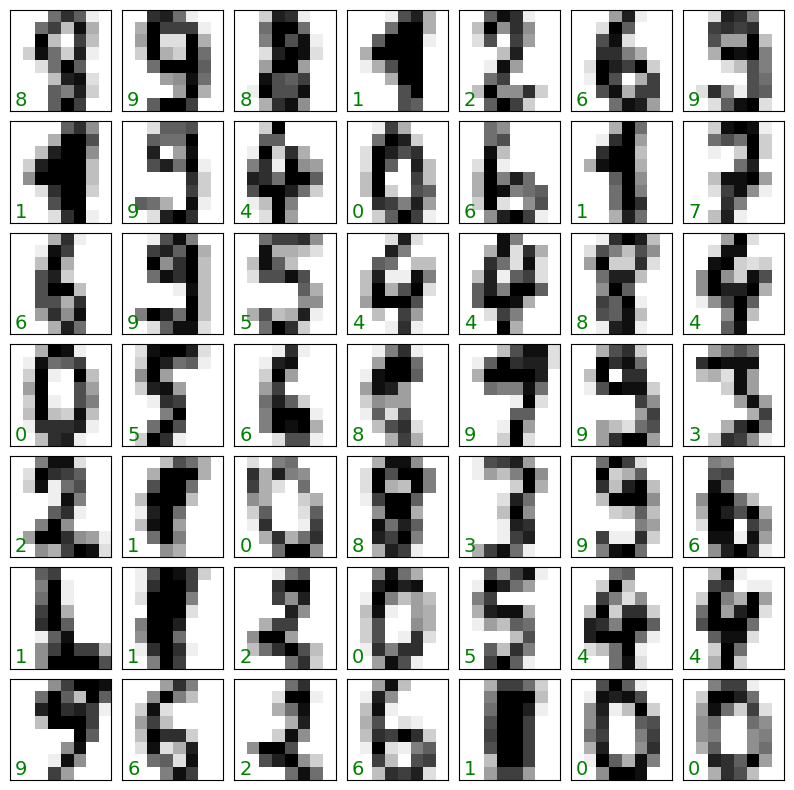

In [8]:
digits = datasets.load_digits()
y = digits.target
X = digits.data

fig, axes = plt.subplots(7,7, figsize=(10, 10))
fig.subplots_adjust(hspace=0.1, wspace=0.1)

np.random.seed(4321) #### This was the seed
mychoices = np.random.choice(digits.images.shape[0],49)
np.random.seed()

for i, ax in enumerate(axes.flat):
    ax.imshow((digits.images[mychoices[i]]), 
              cmap='binary')
    ax.text(0.05, 0.05, str(digits.target[mychoices[i]]),transform=ax.transAxes, color='green', fontsize=14)
    ax.set_xticks([])
    ax.set_yticks([])

np.random.seed(42)

Transform from 64 components to 2 components

C:\Anaconda\Lib\site-packages\sklearn\manifold\_isomap.py:383: UserWarning: The number of connected components of the neighbors graph is 2 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
C:\Anaconda\Lib\site-packages\scipy\sparse\_index.py:100: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_intXint(row, col, x.flat[0])


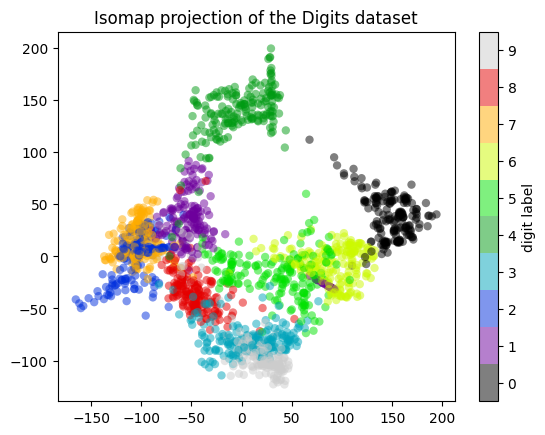

In [9]:
embedding = Isomap(n_components=2)
X_transformed = embedding.fit_transform(X)

# Plot the result
plt.figure()
plt.scatter(X_transformed[:, 0], X_transformed[:, 1], c=y, edgecolor='none', alpha=0.5, 
            cmap=discrete_cmap(10,'nipy_spectral'))
plt.colorbar(label='digit label', ticks=range(10))
plt.clim(-0.5, 9.5)
plt.title("Isomap projection of the Digits dataset")
plt.show()

Most of the digits are fairly well identified

Accuracy on training set is:  1.0
Accuracy on test set is:  0.9472222222222222


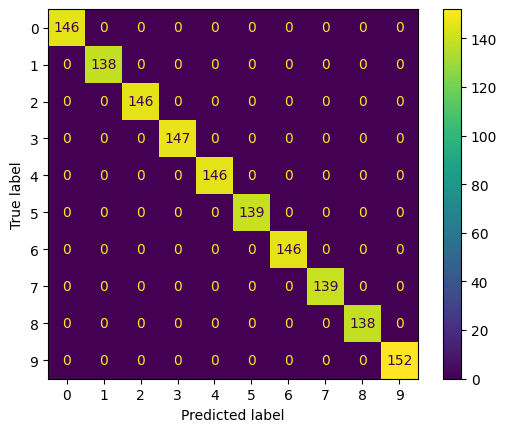

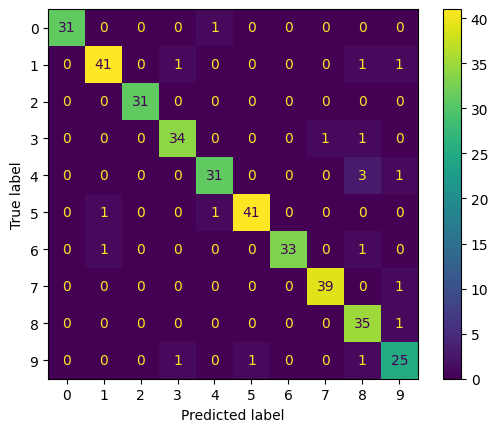

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.80,random_state=2)
clf = LogisticRegression(max_iter=2000,solver='sag').fit(X_train,y_train)
y_pred_test = clf.predict(X_test)
y_pred_train = clf.predict(X_train)

print('Accuracy on training set is: ', accuracy_score(y_train, y_pred_train))
print('Accuracy on test set is: ', accuracy_score(y_test, y_pred_test))

confusion_matrix(y_train, y_pred_train, labels=range(10))
ConfusionMatrixDisplay.from_predictions(y_train, y_pred_train)

confusion_matrix(y_test, y_pred_test, labels=range(10))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test)

Let's see visually how the algorithm performs on the digits

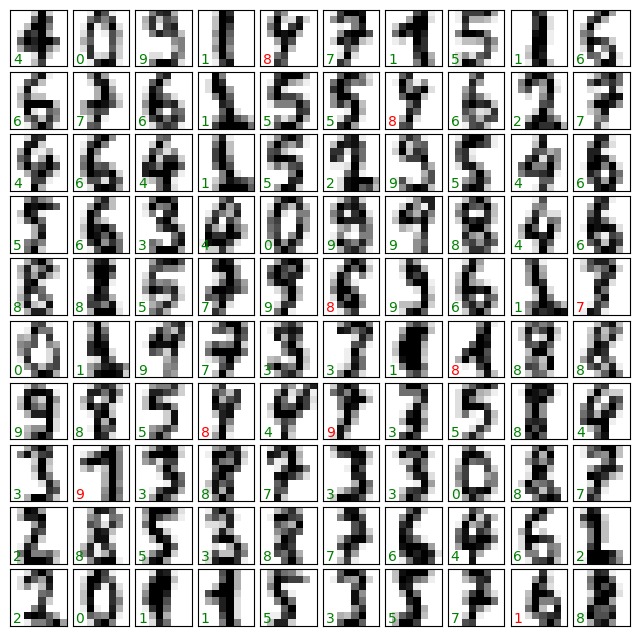

In [11]:
fig, axes = plt.subplots(10, 10, figsize=(8, 8))
fig.subplots_adjust(hspace=0.1, wspace=0.1)

for i, ax in enumerate(axes.flat):
    ax.imshow((X_test[i].reshape(8, 8)), cmap='binary')
    ax.text(0.05, 0.05, str(y_pred_test[i]), transform=ax.transAxes, 
            color='green' if (y_test[i] == y_pred_test[i]) else 'red')
    ax.set_xticks([])
    ax.set_yticks([])

If i use the dimension reduced data set, the performances are much morse

Accuracy on training set is:  0.6840640222686152
Accuracy on test set is:  0.6638888888888889


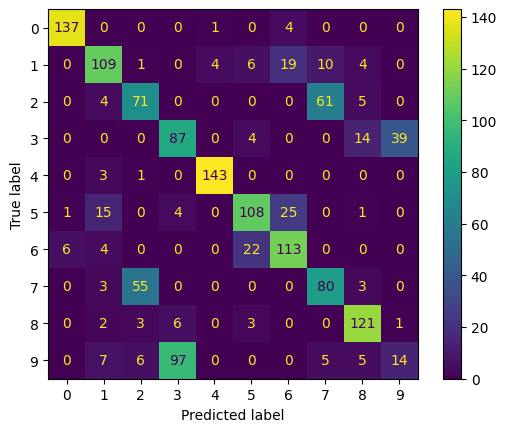

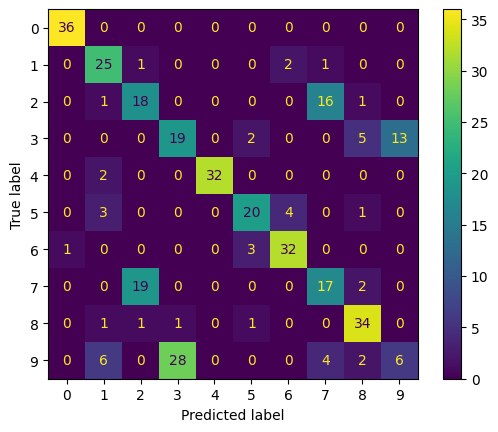

In [12]:
# the accuracy reduces when using the "reducted" data set
# also you need a max_iter very high to converge
X_train, X_test, y_train, y_test = train_test_split(X_transformed, y, train_size=0.80)

clf = LogisticRegression(solver='sag', max_iter=10000).fit(X_train,y_train)
y_pred_test = clf.predict(X_test)
y_pred_train = clf.predict(X_train)

print('Accuracy on training set is: ', accuracy_score(y_train, y_pred_train))
print('Accuracy on test set is: ', accuracy_score(y_test, y_pred_test))

confusion_matrix(y_train, y_pred_train, labels=range(10))
ConfusionMatrixDisplay.from_predictions(y_train, y_pred_train)

confusion_matrix(y_test, y_pred_test, labels=range(10))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test)